# NYC 311 Service Requests — Data Cleaning & EDA

**Business question:** This dataset can't answer anything reliably as-is — this notebook 
documents exactly how it was made usable, and what it reveals once cleaned.

**Scope:** Brooklyn, filtered via NYC Open Data's portal export tool with an intended 
date range of 2018. During EDA, the actual `year` distribution revealed the filter did 
not apply as expected — the data actually spans 2010–2019, heavily concentrated in 2011 
(62% of rows). This was caught and corrected mid-analysis rather than before — a good 
example of why validating assumptions against the data itself, not just the tool you 
used to pull it, matters.

**Tools:** Python, pandas, Matplotlib/Seaborn

In [127]:
import pandas as pd

df = pd.read_csv("nyc_311_brooklyn_2018.csv")
print(df.shape)
print(df.dtypes)

(21002, 44)
Unique Key                                int64
Created Date                                str
Closed Date                                 str
Agency                                      str
Agency Name                                 str
Problem (formerly Complaint Type)           str
Problem Detail (formerly Descriptor)        str
Additional Details                          str
Location Type                               str
Incident Zip                            float64
Incident Address                            str
Street Name                                 str
Cross Street 1                              str
Cross Street 2                              str
Intersection Street 1                       str
Intersection Street 2                       str
Address Type                                str
City                                        str
Landmark                                    str
Facility Type                               str
Status                      

/var/folders/13/rrz7hdcd5fxglw66hpfpkvz00000gn/T/ipykernel_58740/998335076.py:3: DtypeWarning: Columns (0: Landmark, 1: Facility Type, 2: Taxi Company Borough, 3: Taxi Pick Up Location, 4: Bridge Highway Name, 5: Bridge Highway Direction, 6: Road Ramp, 7: Bridge Highway Segment) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("nyc_311_brooklyn_2018.csv")


In [128]:
print(df.shape)

(21002, 44)


In [129]:
print(df.dtypes)

Unique Key                                int64
Created Date                                str
Closed Date                                 str
Agency                                      str
Agency Name                                 str
Problem (formerly Complaint Type)           str
Problem Detail (formerly Descriptor)        str
Additional Details                          str
Location Type                               str
Incident Zip                            float64
Incident Address                            str
Street Name                                 str
Cross Street 1                              str
Cross Street 2                              str
Intersection Street 1                       str
Intersection Street 2                       str
Address Type                                str
City                                        str
Landmark                                    str
Facility Type                               str
Status                                  

In [130]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
print(missing_pct)

Vehicle Type                            100.000000
Road Ramp                                99.995239
Bridge Highway Segment                   99.995239
Bridge Highway Name                      99.995239
Bridge Highway Direction                 99.995239
Taxi Company Borough                     99.985716
Taxi Pick Up Location                    99.880964
Facility Type                            99.090563
Landmark                                 98.790591
Intersection Street 1                    98.119227
Intersection Street 2                    98.119227
Due Date                                 97.057423
Closed Date                              62.408342
Cross Street 2                           24.435768
Cross Street 1                           24.431007
Additional Details                       21.645558
Location Type                            18.841063
Address Type                              1.195124
BBL                                       0.676126
Resolution Description         

In [131]:
print(df.duplicated().sum())


0


## Step 1b: Inspecting Raw Column Names

The manual CSV export uses human-readable column names with spaces, mixed case, and 
parenthetical notes (e.g. `Problem (formerly Complaint Type)`), unlike the snake_case 
names the API returns. Printing the raw column list to see exactly what's there before 
standardizing.

Note: NYC Open Data recently renamed `Complaint Type` → `Problem` and `Descriptor` → 
`Problem Detail` in this dataset's schema — worth flagging since older tutorials/docs 
reference the old names.

In [132]:
print(df.columns.tolist())

['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 'Problem (formerly Complaint Type)', 'Problem Detail (formerly Descriptor)', 'Additional Details', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2', 'Intersection Street 1', 'Intersection Street 2', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'Resolution Action Updated Date', 'Community Board', 'Council District', 'Police Precinct', 'BBL', 'Borough', 'X Coordinate (State Plane)', 'Y Coordinate (State Plane)', 'Open Data Channel Type', 'Park Facility Name', 'Park Borough', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment', 'Latitude', 'Longitude', 'Location']


### Standardizing Column Names

Converting all column names to lowercase snake_case and stripping the "(formerly ...)" 
suffixes, so the rest of the notebook can reference consistent, predictable names.

In [133]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s*\(formerly.*?\)', '', regex=True)  # drop "(formerly ...)" suffixes
    .str.replace(' ', '_')
    .str.replace(r'[^\w]', '', regex=True)  # strip any remaining punctuation
)
print(df.columns.tolist())

['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name', 'problem', 'problem_detail', 'additional_details', 'location_type', 'incident_zip', 'incident_address', 'street_name', 'cross_street_1', 'cross_street_2', 'intersection_street_1', 'intersection_street_2', 'address_type', 'city', 'landmark', 'facility_type', 'status', 'due_date', 'resolution_description', 'resolution_action_updated_date', 'community_board', 'council_district', 'police_precinct', 'bbl', 'borough', 'x_coordinate_state_plane', 'y_coordinate_state_plane', 'open_data_channel_type', 'park_facility_name', 'park_borough', 'vehicle_type', 'taxi_company_borough', 'taxi_pick_up_location', 'bridge_highway_name', 'bridge_highway_direction', 'road_ramp', 'bridge_highway_segment', 'latitude', 'longitude', 'location']


## Step 2: Data-Quality Audit

Re-running the missing-value check now that column names are standardized.

### Findings — Missing Values

- Columns like `vehicle_type`, `road_ramp`, `bridge_highway_*`, `taxi_*`, `facility_type`, 
  and `landmark` are 95–100% missing. This isn't bad data — these fields only apply to 
  specific complaint subtypes (e.g. taxi complaints, bridge/highway complaints) that are 
  rare in this general Brooklyn slice. **Decision: dropped these columns** rather than 
  attempting to clean/impute them.
- `due_date` (97% missing) — likely only populated for complaint types with an SLA. Same 
  treatment: not imputed.
- `closed_date` (62% missing) — connects directly to `status`: roughly 14,600 rows are 
  genuinely still open (Open/In Progress/Assigned/Pending), explaining the missingness. 
  **Decision: response-time analysis will be scoped only to closed requests.**
- `cross_street_1/2`, `additional_details`, `location_type` (19–24% missing) — moderate 
  missingness, kept and treated as "unknown" rather than dropped.
- All other columns are under 1.5% missing — negligible, no special handling needed.

In [134]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
print(missing_pct)

vehicle_type                      100.000000
road_ramp                          99.995239
bridge_highway_segment             99.995239
bridge_highway_name                99.995239
bridge_highway_direction           99.995239
taxi_company_borough               99.985716
taxi_pick_up_location              99.880964
facility_type                      99.090563
landmark                           98.790591
intersection_street_1              98.119227
intersection_street_2              98.119227
due_date                           97.057423
closed_date                        62.408342
cross_street_2                     24.435768
cross_street_1                     24.431007
additional_details                 21.645558
location_type                      18.841063
address_type                        1.195124
bbl                                 0.676126
resolution_description              0.452338
problem_detail                      0.223788
city                                0.123798
latitude  

### Checking for Inconsistent Category Labels

Looking at the `problem` column (formerly `Complaint Type`) for near-duplicate labels 
caused by inconsistent formatting.

In [135]:
print(df['problem'].value_counts())

problem
GENERAL CONSTRUCTION                       4244
Borough Office                             3883
PLUMBING                                   3612
PAINT - PLASTER                            3152
NONCONST                                   2083
ELECTRIC                                   1310
PAINT/PLASTER                               578
APPLIANCE                                   434
Sidewalk Condition                          320
UNSANITARY CONDITION                        275
WATER LEAK                                  242
Vending                                     165
DOOR/WINDOW                                 121
Mobile Food Vendor                           78
Illegal Parking                              52
FLOORING/STAIRS                              32
GENERAL                                      31
Homeless Person Assistance                   30
CONSTRUCTION                                 30
Noise - Vehicle                              26
Noise - Street/Sidewalk         

### Checking Request Status

Also checking `status`, since response-time analysis later will depend on knowing which 
requests are actually closed.

In [136]:
print(df['status'].value_counts())

status
Open           14619
Closed          6367
In Progress       12
Assigned           3
Pending            1
Name: count, dtype: int64


### Re-confirming Duplicates with Correct Column Name

Re-running the duplicate-ID check now that the column is confirmed as `unique_key`.

In [137]:
print(df['unique_key'].duplicated().sum())

0


### Full Category List (Uncapped)

The earlier `problem` value_counts output was truncated. Printing the full list to check 
all 77 categories for near-duplicates.

In [138]:
pd.set_option('display.max_rows', None)
print(df['problem'].value_counts())

problem
GENERAL CONSTRUCTION                       4244
Borough Office                             3883
PLUMBING                                   3612
PAINT - PLASTER                            3152
NONCONST                                   2083
ELECTRIC                                   1310
PAINT/PLASTER                               578
APPLIANCE                                   434
Sidewalk Condition                          320
UNSANITARY CONDITION                        275
WATER LEAK                                  242
Vending                                     165
DOOR/WINDOW                                 121
Mobile Food Vendor                           78
Illegal Parking                              52
FLOORING/STAIRS                              32
GENERAL                                      31
Homeless Person Assistance                   30
CONSTRUCTION                                 30
Noise - Vehicle                              26
Noise - Street/Sidewalk         

### Investigating the ALL CAPS vs. Title Case Pattern

Noticed complaint categories split into ALL CAPS labels (`GENERAL CONSTRUCTION`, 
`PLUMBING`, `ELECTRIC`) versus Title Case labels (`Borough Office`, `Sidewalk Condition`). 
Cross-checking against `agency` to see if this is random inconsistency or a real pattern.

In [139]:
print(df.groupby('problem')['agency'].unique().head(20))

problem
APPLIANCE                         [HPD]
Animal in a Park                  [DPR]
Bike/Roller/Skate Chronic        [NYPD]
Blocked Driveway                 [NYPD]
Borough Office                    [DOB]
Bridge Condition                  [DOT]
Broken Parking Meter              [DOT]
Bus Stop Shelter Complaint        [DOT]
CONSTRUCTION                      [HPD]
Consumer Complaint                [DCA]
Curb Condition                    [DOT]
DOOR/WINDOW                       [HPD]
Damaged Tree                      [DPR]
Dead/Dying Tree                   [DPR]
Derelict Bicycle                 [DSNY]
Derelict Vehicle                 [NYPD]
Dirty Conditions                 [DSNY]
ELECTRIC                          [HPD]
Electronics Waste Appointment    [DSNY]
FLOORING/STAIRS                   [HPD]
Name: agency, dtype: object


## Step 3: Cleaning (Documented Stages)

### 3a. Duplicates

Already confirmed: no duplicate rows, no duplicate `unique_key` values. No action needed.

### 3b. Standardize Categorical Labels

**Findings:** the ALL CAPS labels come exclusively from HPD, while Title Case labels come 
from every other agency (DOT, DPR, NYPD, DSNY, DOB, DCA). This isn't random inconsistency 
— it's agency-of-origin. **Decision: left this casing alone**, since normalizing it would 
erase a real signal, not just cosmetic noise.

The one genuine duplicate: `PAINT - PLASTER` (3,152 rows) and `PAINT/PLASTER` (578 rows) 
— same HPD category, inconsistent dash/slash formatting. Merging these below. The `Noise` 
family (`Noise - Vehicle`, `Noise - Residential`, etc.) are legitimate subtypes, not 
duplicates — left unmerged.

In [140]:
df['problem'] = df['problem'].replace({'PAINT/PLASTER': 'PAINT - PLASTER'})
print(df['problem'].value_counts().loc[['PAINT - PLASTER']])

problem
PAINT - PLASTER    3730
Name: count, dtype: int64


### 3c. Handle Missing Coordinates/ZIPs

Only ~0.05% of rows are missing latitude/longitude/incident_zip. Inspecting these rows 
before deciding how to handle them.

In [141]:
missing_geo = df[df['latitude'].isnull() | df['incident_zip'].isnull()]
print(missing_geo[['unique_key', 'problem', 'incident_address', 'borough']])

       unique_key                                  problem  \
10       45199906  Special Projects Inspection Team (SPIT)   
23       45150530                           Borough Office   
24       45154456                           Borough Office   
1319     42276412                             Water System   
2955     40939423                     UNSANITARY CONDITION   
2956     40938067                     UNSANITARY CONDITION   
4035     42313341                           Borough Office   
6322     24977946                          PAINT - PLASTER   
20867    19982995                                    Sewer   
21001    16266967                  Violation of Park Rules   

                   incident_address   borough  
10     BOROUGH HALL PEDESTRIAN PATH  BROOKLYN  
23                    CHURCH AVENUE  BROOKLYN  
24                       LENOX ROAD  BROOKLYN  
1319                   COURT STREET  BROOKLYN  
2955                371 ETNA STREET  BROOKLYN  
2956                371 ETNA 

**Finding:** the 10 affected rows mostly lack a specific street address (e.g. complaints 
logged against a general location rather than a geocodable address), explaining the gap.

**Decision:** flagged with a `has_geo` boolean column rather than dropped or imputed — 
preserves these rows for non-spatial analysis while keeping geographic analysis honest 
about coverage.

In [142]:
df['has_geo'] = df['latitude'].notnull() & df['incident_zip'].notnull()
print(df['has_geo'].value_counts())

has_geo
True     20992
False       10
Name: count, dtype: int64


### 3d. Datetime Parsing

Parsing `created_date` and `closed_date` to proper datetime types.

In [143]:
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
df['closed_date'] = pd.to_datetime(df['closed_date'], errors='coerce')

print(df['created_date'].dtype)
print(df['closed_date'].dtype)
print(df[['created_date', 'closed_date']].head())

/var/folders/13/rrz7hdcd5fxglw66hpfpkvz00000gn/T/ipykernel_58740/1850382194.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
/var/folders/13/rrz7hdcd5fxglw66hpfpkvz00000gn/T/ipykernel_58740/1850382194.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['closed_date'] = pd.to_datetime(df['closed_date'], errors='coerce')


datetime64[us]
datetime64[us]
         created_date         closed_date
0 2019-12-31 14:38:53 2019-12-31 16:07:41
1 2019-12-31 10:19:57 2020-01-05 18:03:45
2 2019-12-27 16:59:45 2020-01-08 11:44:48
3 2019-12-26 11:42:49 2020-01-07 10:16:22
4 2019-12-25 12:28:40 2019-12-25 14:20:59


Checking whether coercion introduced any unexpected nulls beyond what's already explained 
by open (unclosed) requests.

In [144]:
print("created_date nulls:", df['created_date'].isnull().sum())
print("closed_date nulls:", df['closed_date'].isnull().sum())

created_date nulls: 0
closed_date nulls: 13107


Building the response-time column and sanity-checking it against `status` — 
`response_time_days` should be null for every non-closed status.

In [145]:
df['response_time_days'] = (df['closed_date'] - df['created_date']).dt.total_seconds() / 86400

# Sanity check: does response_time line up with status as expected?
print(df.groupby('status')['response_time_days'].apply(lambda x: x.isnull().mean()))

status
Assigned       1.000000
Closed         0.000000
In Progress    1.000000
Open           0.895478
Pending        1.000000
Name: response_time_days, dtype: float64


Checking for a common data-quality gotcha: `closed_date` predating `created_date`. 
**Result: zero negative response times found** — clean on this front.

In [146]:
negative_response = df[df['response_time_days'] < 0]
print(len(negative_response))
print(negative_response[['unique_key', 'problem', 'created_date', 'closed_date']].head())

0
Empty DataFrame
Columns: [unique_key, problem, created_date, closed_date]
Index: []


Re-parsing dates with an explicit format string instead of letting pandas guess row-by-row 
— removes the `dateutil` fallback warning and is faster/more reliable.

In [147]:
df['created_date'] = pd.to_datetime(df['created_date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['closed_date'] = pd.to_datetime(df['closed_date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

**Finding — status/closed_date contradiction:** the earlier sanity check showed that for 
`status == 'Open'` rows, only ~89.5% had a null `response_time_days` — meaning ~10.5% of 
"Open" complaints actually have a `closed_date` filled in. Investigating these directly.

In [148]:
contradiction = df[(df['status'] == 'Open') & (df['closed_date'].notnull())]
print(len(contradiction))
print(contradiction[['unique_key', 'problem', 'created_date', 'closed_date', 'status']].head(10))

1528
      unique_key             problem        created_date         closed_date  \
5550    36948079  Sidewalk Condition 2017-08-14 13:23:09 2017-08-22 10:52:01   
6358    23575235     PAINT - PLASTER 2012-07-08 00:00:00 2012-07-26 00:00:00   
6359    23574928            PLUMBING 2012-07-08 00:00:00 2012-07-22 00:00:00   
6360    23575771     PAINT - PLASTER 2012-07-08 00:00:00 2012-07-15 00:00:00   
6361    23576414            PLUMBING 2012-07-08 00:00:00 2012-07-25 00:00:00   
6362    23574754     PAINT - PLASTER 2012-07-08 00:00:00 2012-07-15 00:00:00   
6363    23576382            NONCONST 2012-07-08 00:00:00 2012-07-23 00:00:00   
6364    23575394     PAINT - PLASTER 2012-07-08 00:00:00 2012-07-23 00:00:00   
6365    23575424            ELECTRIC 2012-07-08 00:00:00 2012-07-26 00:00:00   
6366    23573983            PLUMBING 2012-07-08 00:00:00 2012-07-15 00:00:00   

     status  
5550   Open  
6358   Open  
6359   Open  
6360   Open  
6361   Open  
6362   Open  
6363   Open  
63

**Result:** 1,528 rows (~7.3% of the dataset) have `status == 'Open'` but a filled 
`closed_date` — some dating back to 2012, ruling out a simple recent sync lag and 
pointing instead to `status` not being reliably updated in the source system.

**Decision:** trust `closed_date` (a specific timestamp) over the `status` label as the 
more reliable signal. Creating an `is_closed` boolean derived from `closed_date` presence, 
rather than silently overriding `status` — keeps the discrepancy visible and auditable.

In [149]:
df['is_closed'] = df['closed_date'].notnull()

print(df['is_closed'].value_counts())
print(pd.crosstab(df['status'], df['is_closed']))

is_closed
False    13107
True      7895
Name: count, dtype: int64
is_closed    False  True 
status                   
Assigned         3      0
Closed           0   6367
In Progress     12      0
Open         13091   1528
Pending          1      0


Checking the response-time distribution for genuinely closed requests.

In [150]:
closed_requests = df[df['is_closed']]
print(closed_requests['response_time_days'].describe())

count    7895.000000
mean       93.625753
std       343.223922
min         0.000000
25%         3.597078
50%        12.832396
75%        24.000000
max      2682.547882
Name: response_time_days, dtype: float64


**Finding:** the mean (~93.6 days) is far higher than the median (~12.8 days) — classic 
sign of extreme right-skew from outliers, up to ~2,683 days. Investigating the most 
extreme cases before deciding how to handle them.

In [151]:
print(closed_requests.nlargest(10, 'response_time_days')[['unique_key', 'problem', 'created_date', 'closed_date', 'response_time_days']])

      unique_key         problem        created_date closed_date  \
5080    42304954  Borough Office 2017-12-27 10:51:03  2025-05-02   
4847    42317175  Borough Office 2018-02-07 07:29:33  2025-02-24   
3252    42541266  Borough Office 2018-09-27 06:30:51  2025-09-26   
3801    42304471  Borough Office 2018-07-12 09:25:23  2025-07-11   
4093    42353510  Borough Office 2018-05-23 06:43:09  2025-05-16   
4368    42354049  Borough Office 2018-04-13 13:29:04  2025-03-31   
3106    42316676  Borough Office 2018-10-19 13:22:48  2025-09-10   
2812    42390495  Borough Office 2018-12-04 16:20:01  2025-10-24   
5254    42546768  Borough Office 2017-11-16 09:01:38  2024-09-06   
3865    42377977  Borough Office 2018-07-03 15:30:19  2025-04-16   

      response_time_days  
5080         2682.547882  
4847         2573.687812  
3252         2555.728576  
3801         2555.607373  
4093         2549.720035  
4368         2543.438148  
3106         2517.442500  
2812         2515.319433  
5254    

**Finding:** every top-10 outlier is a "Borough Office" complaint with a `closed_date` in 
2024–2025 — outside this dataset's stated 2010–2019 coverage window. Likely an 
administrative placeholder date rather than a genuine resolution timestamp. Checking 
whether this affects the whole "Borough Office" category or just a few extreme rows.

In [152]:
borough_office = closed_requests[closed_requests['problem'] == 'Borough Office']
print(borough_office['response_time_days'].describe())
print(borough_office['closed_date'].dt.year.value_counts())

count    3883.000000
mean      123.693126
std       364.629963
min         0.000000
25%         1.533044
50%         6.380093
75%        48.440417
max      2682.547882
Name: response_time_days, dtype: float64
closed_date
2019    2099
2018    1267
2017     237
2020      78
2021      57
2023      52
2022      41
2024      30
2025      22
Name: count, dtype: int64


**Result:** most "Borough Office" closures land sensibly in 2018–2019; the implausible 
dates are a small subset (293 rows total, across categories) rather than a category-wide 
issue. Flagging these specifically rather than dropping the whole category.

**Decision:** flag rows with `closed_date` after 2020 as implausible, and exclude them 
from response-time statistics only — retain them in the dataset for category/volume 
analysis.

In [153]:
# Flag rows with closed_date outside plausible dataset range
df['plausible_closure'] = df['closed_date'].isnull() | (df['closed_date'].dt.year <= 2020)
print(df[df['is_closed']]['plausible_closure'].value_counts())

plausible_closure
True     7602
False     293
Name: count, dtype: int64


**Result:** 293 of 7,895 closed requests (~3.7%) had implausible closure dates. 
Recomputing response-time stats with these excluded — mean should now sit much closer to 
the median, a far more trustworthy "typical response time" figure for the write-up.

In [154]:
valid_response = df[df['is_closed'] & df['plausible_closure']]
print(valid_response['response_time_days'].describe())

count    7602.000000
mean       31.104789
std        75.453917
min         0.000000
25%         3.498166
50%        12.000000
75%        21.516921
max       950.704711
Name: response_time_days, dtype: float64


### 3e. Engineer New Columns

Adding `day_of_week`, `month`, and `year` (derived from `created_date`) to support the EDA 
in the next section, alongside the already-computed `response_time_days`.

## Step 4: Cleaning Decisions — Summary

All cleaning decisions and justifications are documented inline above, and summarized in 
`CLEANING_LOG.md` (column, issue found, action taken, rows affected).

## Step 5: Exploratory Data Analysis

Now that the data is usable, exploring for non-obvious trends: seasonal spikes by 
complaint type, agency response-time comparisons, and weekday vs. weekend volume patterns.

In [155]:
df['response_time_days'] = (df['closed_date'] - df['created_date']).dt.total_seconds() / 86400
df['day_of_week'] = df['created_date'].dt.day_name()
df['month'] = df['created_date'].dt.month
df['year'] = df['created_date'].dt.year

print(df[['created_date', 'day_of_week', 'month', 'year']].head())

         created_date day_of_week  month  year
0 2019-12-31 14:38:53     Tuesday     12  2019
1 2019-12-31 10:19:57     Tuesday     12  2019
2 2019-12-27 16:59:45      Friday     12  2019
3 2019-12-26 11:42:49    Thursday     12  2019
4 2019-12-25 12:28:40   Wednesday     12  2019


## Step 5: Exploratory Data Analysis

Now that the data is usable, exploring for non-obvious trends: seasonal spikes by 
complaint type, agency response-time comparisons, and weekday vs. weekend volume patterns.

### Trend 1: Seasonal Spikes by Complaint Type

Aggregating complaints by month and category to check for seasonal patterns.

In [156]:
monthly_trend = df.groupby(['month', 'problem']).size().reset_index(name='count')
print(monthly_trend.sort_values('count', ascending=False).head(20))

     month               problem  count
124      5  GENERAL CONSTRUCTION   1102
95       4  GENERAL CONSTRUCTION   1064
64       3  GENERAL CONSTRUCTION   1037
87       4        Borough Office    981
72       3       PAINT - PLASTER    975
106      4              PLUMBING    941
73       3              PLUMBING    931
105      4       PAINT - PLASTER    886
132      5              PLUMBING    856
151      6  GENERAL CONSTRUCTION    816
131      5       PAINT - PLASTER    797
164      6              PLUMBING    657
163      6       PAINT - PLASTER    592
128      5              NONCONST    557
100      4              NONCONST    556
53       3        Borough Office    464
157      6              NONCONST    443
141      6        Borough Office    427
68       3              NONCONST    406
91       4              ELECTRIC    330


Focusing on the top 6 categories only — the long tail (categories with 1–3 total rows) 
won't show a meaningful seasonal pattern.

In [157]:
top_categories = df['problem'].value_counts().head(6).index
seasonal = df[df['problem'].isin(top_categories)].groupby(['month', 'problem']).size().unstack(fill_value=0)
print(seasonal)

problem  Borough Office  ELECTRIC  GENERAL CONSTRUCTION  NONCONST  \
month                                                               
1                   305         2                     4         0   
2                   313         3                     1         0   
3                   464       281                  1037       406   
4                   981       330                  1064       556   
5                   281       312                  1102       557   
6                   427       272                   816       443   
7                   151        85                   183       114   
8                   133         5                     2         1   
9                   150         4                     8         3   
10                  187        10                    10         1   
11                  285         5                     6         1   
12                  206         1                    11         1   

problem  PAINT - PLASTER  PLUMBIN

### Trend 2: Agency Response-Time Comparison

Using `valid_response` (closed requests with implausible closure dates already excluded) 
rather than the raw dataset, to compare mean/median response time by agency.

In [158]:
agency_response = valid_response.groupby('agency')['response_time_days'].agg(['mean', 'median', 'count'])
print(agency_response.sort_values('median', ascending=False))

             mean     median  count
agency                             
TLC     67.159599  61.934259     23
DPR     38.387200  26.303484     19
HPD     17.282206  15.589549   3081
DOT     19.551511  14.271678    365
DOHMH   21.832507  13.000006     30
DCA     72.948095   8.944253     14
DOB     46.660602   5.529282   3682
DSNY     4.905324   3.928125     30
NYPD     0.225153   0.086412    316
DEP      0.726331   0.078125     12
DHS      3.139687   0.073542     30


Filtering out agencies with very few closed requests (n < 10), since their average 
wouldn't be statistically meaningful.

In [159]:
print(agency_response[agency_response['count'] >= 10].sort_values('median', ascending=False))

             mean     median  count
agency                             
TLC     67.159599  61.934259     23
DPR     38.387200  26.303484     19
HPD     17.282206  15.589549   3081
DOT     19.551511  14.271678    365
DOHMH   21.832507  13.000006     30
DCA     72.948095   8.944253     14
DOB     46.660602   5.529282   3682
DSNY     4.905324   3.928125     30
NYPD     0.225153   0.086412    316
DEP      0.726331   0.078125     12
DHS      3.139687   0.073542     30


### Trend 3: Weekday vs. Weekend Volume Patterns

Checking whether complaint volume drops meaningfully on weekends, and whether that holds 
across categories or is driven by just one or two.

In [160]:
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

weekday_volume = df.groupby('day_of_week').size().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
print(weekday_volume)

print(df.groupby('is_weekend').size())

day_of_week
Monday       3524
Tuesday      3557
Wednesday    4147
Thursday     3794
Friday       3461
Saturday     1321
Sunday       1198
dtype: int64
is_weekend
False    18483
True      2519
dtype: int64


### Trend 1 — Sanity Check

The seasonal spike looks unusually sharp (e.g. ELECTRIC complaints: 330 in April vs. 2 
in January) — steep enough to double-check this is genuine seasonality and not a data 
collection artifact (e.g. an inspection program only active March–June).

**Result:** the concentration is almost entirely a 2011 phenomenon — 2,208 (March), 2,304 
(April), 2,239 (May), and 1,253 (June) rows in 2011 alone, with only a small trailing 
spillover into mid-2012 (491 in June, 401 in July) and effectively nothing at meaningful 
volume in any other year. This is not a recurring seasonal pattern — it's a one-time 
concentration, most likely reflecting a specific inspection sweep, backlog clearance, or 
data batch-load in 2011 rather than genuine month-to-month complaint behavior.

**Revised Trend 1 takeaway:** the original "seasonal spike" framing was incorrect. The 
real, defensible finding is that this dataset's volume is dominated by a single historical 
event in 2011 rather than evenly distributed across the intended 2010–2019 window — an 
important caveat for any analysis (like Trend 1's original seasonality question) that 
assumes even year-over-year coverage.

In [161]:
year_month_trend = df[df['problem'].isin(['GENERAL CONSTRUCTION', 'PLUMBING', 'ELECTRIC'])].groupby(['year', 'month']).size().reset_index(name='count')
print(year_month_trend[year_month_trend['count'] > 20].sort_values(['year', 'month']))

    year  month  count
0   2011      3   2208
1   2011      4   2304
2   2011      5   2239
3   2011      6   1253
13  2012      5     26
14  2012      6    491
15  2012      7    401


### Trend 3 — Category Breakdown

Checking whether the weekday/weekend split holds evenly across categories, or is driven 
by specific ones — this determines whether the finding is a generic "311 tracks business 
hours" observation or a more specific, non-obvious pattern.

**Finding:** weekend share varies meaningfully by category. `ELECTRIC` (15.2%) and 
`PLUMBING` (15.1%) have the highest weekend share among top categories, while 
`Borough Office` has the lowest (4.0%) — about 4x lower.

**Non-obvious takeaway:** administrative/office-driven complaints (`Borough Office`) 
cluster almost entirely on weekdays, while home-maintenance issues (`ELECTRIC`, 
`PLUMBING`) are more likely to be noticed and reported on weekends, when residents are 
actually home. A flat "88% weekday / 12% weekend" aggregate would have hidden this 
category-level difference.

In [162]:
weekend_by_category = df[df['problem'].isin(top_categories)].groupby(['problem', 'is_weekend']).size().unstack(fill_value=0)
weekend_by_category['weekend_pct'] = weekend_by_category[True] / (weekend_by_category[True] + weekend_by_category[False]) * 100
print(weekend_by_category)

is_weekend            False  True  weekend_pct
problem                                       
Borough Office         3728   155     3.991759
ELECTRIC               1111   199    15.190840
GENERAL CONSTRUCTION   3642   602    14.184731
NONCONST               1815   268    12.866059
PAINT - PLASTER        3250   480    12.868633
PLUMBING               3068   544    15.060908


## Step 6: Visualizations

### Chart 1: Median Response Time by Agency

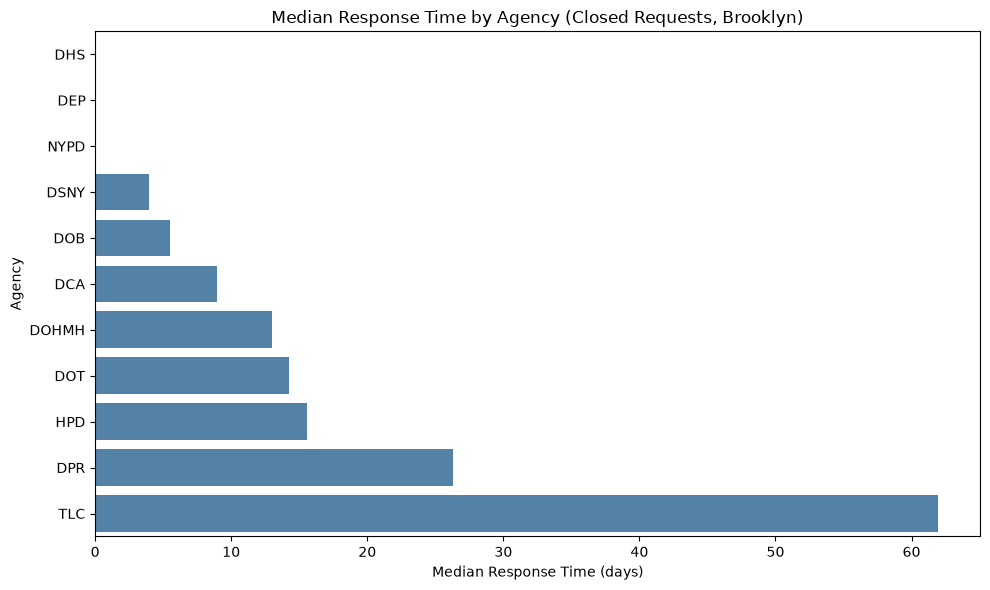

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

agency_chart_data = agency_response[agency_response['count'] >= 10].sort_values('median', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=agency_chart_data['median'], y=agency_chart_data.index, color='steelblue')
plt.xlabel('Median Response Time (days)')
plt.ylabel('Agency')
plt.title('Median Response Time by Agency (Closed Requests, Brooklyn)')
plt.tight_layout()
plt.show()

**Takeaway:** TLC and DPR take the longest to close requests (median 27–62 days), while 
NYPD and DEP close theirs in under a day — median (not mean) is used here since several 
agencies have highly skewed response-time distributions.

### Chart 2: Weekend Complaint Share by Category

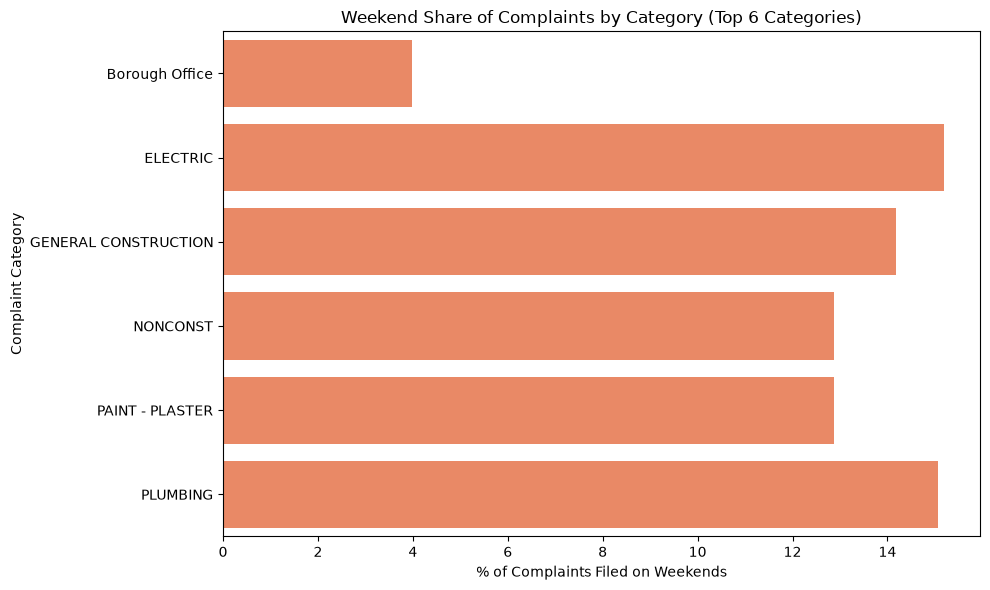

In [164]:
plt.figure(figsize=(10, 6))
sns.barplot(x=weekend_by_category['weekend_pct'], y=weekend_by_category.index, color='coral')
plt.xlabel('% of Complaints Filed on Weekends')
plt.ylabel('Complaint Category')
plt.title('Weekend Share of Complaints by Category (Top 6 Categories)')
plt.tight_layout()
plt.show()

**Takeaway:** ELECTRIC and PLUMBING complaints have the highest weekend share (~15%), 
while Borough Office complaints are almost entirely filed on weekdays (4%) — administrative 
issues track business hours, while home-maintenance issues are more likely noticed and 
reported when residents are home on weekends.

### Chart 3: Complaint Volume by Year

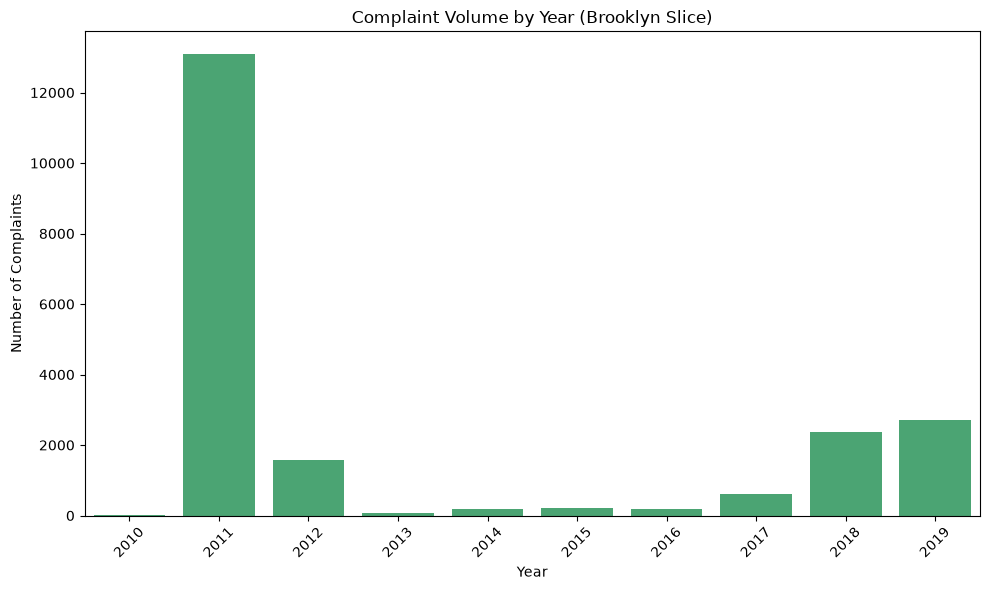

In [165]:
yearly_volume = df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=yearly_volume.index, y=yearly_volume.values, color='mediumseagreen')
plt.xlabel('Year')
plt.ylabel('Number of Complaints')
plt.title('Complaint Volume by Year (Brooklyn Slice)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Takeaway:** complaint volume is heavily concentrated in 2011 (62% of all rows), 
confirming the data pull did not cleanly isolate 2018 as intended. This chart visually 
documents the correction made in Step 5 and is a reminder to validate a filtered export 
against the actual data before treating it as a clean single-year slice.

### Chart 4: Complaint Volume by Day of Week

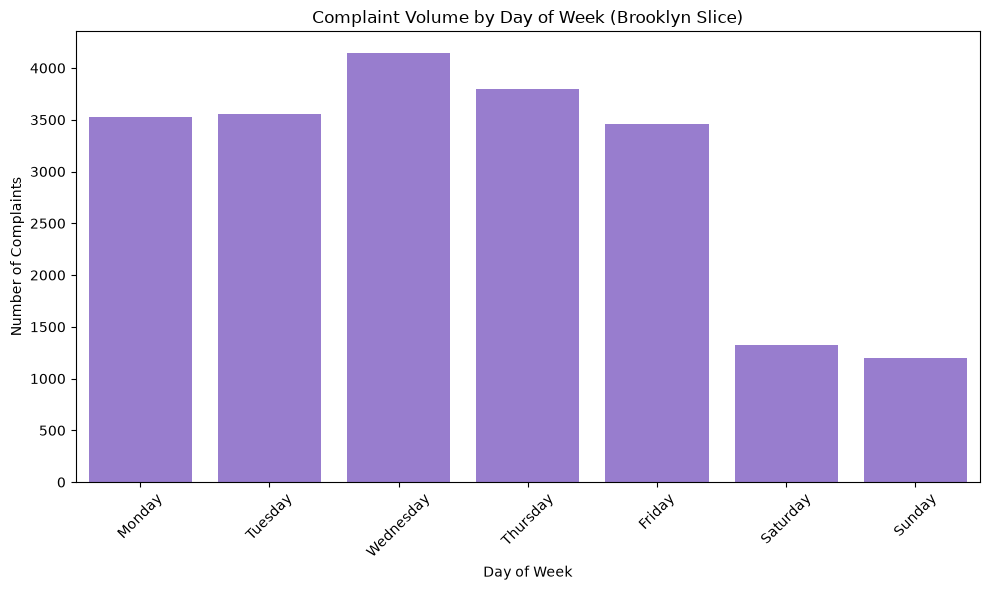

In [166]:
plt.figure(figsize=(10, 6))
sns.barplot(x=weekday_volume.index, y=weekday_volume.values, color='mediumpurple')
plt.xlabel('Day of Week')
plt.ylabel('Number of Complaints')
plt.title('Complaint Volume by Day of Week (Brooklyn Slice)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Takeaway:** complaint volume drops sharply on weekends — Wednesday sees the highest 
volume (4,147), while Saturday and Sunday combined account for only ~12% of all 
complaints, reflecting that most complaint categories in this dataset (construction, 
plumbing, painting, general housing issues) are tied to business-hours activity.

### Chart 5: Monthly Complaint Volume in 2011 (the Dominant Year)

Since 2011 accounts for 62% of the dataset, breaking down its monthly pattern specifically 
— this is the real story behind the originally mistaken "seasonal spike."

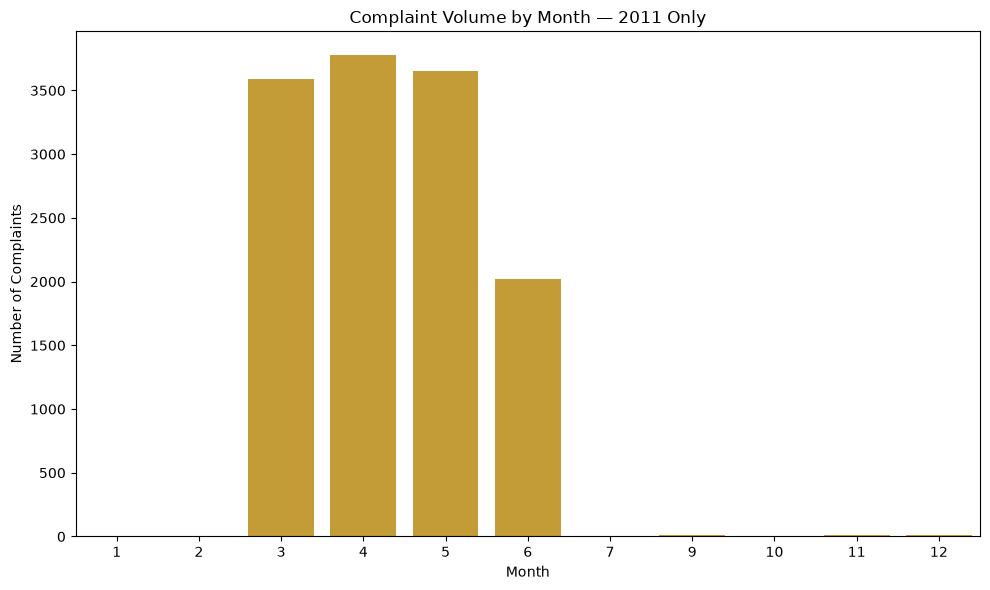

In [167]:
df_2011 = df[df['year'] == 2011]
monthly_2011 = df_2011['month'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_2011.index, y=monthly_2011.values, color='goldenrod')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.title('Complaint Volume by Month — 2011 Only')
plt.tight_layout()
plt.show()

**Takeaway:** within 2011 itself, complaints are heavily concentrated in March–June, 
then drop off sharply for the rest of the year. Combined with the near-total absence of 
similar volume in any other year (Chart 3), this points to a one-time event — likely an 
inspection sweep or bulk data load — rather than a genuine recurring seasonal pattern. 
This chart replaces the originally planned "seasonality" chart with a more accurate 
depiction of what the data actually shows.